In [1]:
'''
RAG to be deployed. Followed concepts of rag part 2 tutorial of langchain, but using a persistent db for storing embeddings (quadrant)
'''

'\nRAG to be deployed. Followed concepts of rag part 2 tutorial of langchain, but using a persistent db for storing embeddings (quadrant)\n'

In [1]:

# Useful to set working directory
from pathlib import Path

# Useful to load api keys for Cohere embeddings and generative model
import os
from dotenv import load_dotenv
load_dotenv()  # Loads from .env
COHERE_API_KEY=os.getenv("COHERE_TOKEN")
os.environ["COHERE_API_KEY"]=COHERE_API_KEY 
from langchain_cohere import CohereEmbeddings
from langchain.chat_models import init_chat_model

# For connecting to the embeddings vector store
from langchain_qdrant import QdrantVectorStore
from qdrant_client import QdrantClient

# For declaring functions as tools to be used by the generative model
from langchain_core.tools import tool

# For declaring nodes
from langchain_core.messages import SystemMessage
from langgraph.graph import MessagesState
from langgraph.prebuilt import ToolNode

#For creating the graph
from langgraph.graph import MessagesState, StateGraph
from langgraph.graph import END
from langgraph.prebuilt import  tools_condition

#For adding memory to the graph
from langgraph.checkpoint.memory import MemorySaver

In [2]:
# Set working directory
try:
    # Works in regular Python scripts
    base_dir = Path(__file__).resolve().parent.parent
except NameError:
    # Fallback for Jupyter notebooks and interactive shells
    base_dir = Path().resolve().parent

In [3]:
# Declare both embeddings and generative models
embeddings = CohereEmbeddings(model="embed-v4.0")
model = init_chat_model("command-a-03-2025", model_provider="cohere") # Cohere api key needs to be as env variable with the name COHERE_API_KEY


In [4]:
# Connect to Qdrant vector store
path_qdrant_vector_store = base_dir / "data" /  "qdrant"
client = QdrantClient(path=path_qdrant_vector_store)
vector_store = QdrantVectorStore(
    client=client,
    collection_name="document_embeddings",
    embedding=embeddings,
)

In [5]:
# Check number of records in the embedding vector store
client.count(collection_name=vector_store.collection_name).count


721

In [6]:
# Approach via Chains
#Our graph will consist of three nodes:

    #1- A node that fields the user input, either generating a query for the retriever or responding directly; (this is cool and we did not have it before)
    #2- A node for the retriever tool that executes the retrieval step
    #3- A node that generates the final response using the retrieved context.


### Tools used in the nodes of the graph: ###

#Tool to retrieve data from embeddings store
#An agent decides which tool to use based on the tool's names, descriptions, and argument schemas
@tool(response_format="content_and_artifact") # This will make it possible for a chat model to call this function
def retrieve(query: str): # This receives a string as input and not a state bc it is not a node. This tool will be added into a node, that needs as input a State
    """Retrieve information related to a query."""
    retrieved_docs = vector_store.similarity_search(query, k=4)
    serialized = "\n\n".join(  #The concatenation of docs as strings was done in the generate function before, and it did not include metadata
        (f"Content: {doc.page_content}") 
        for doc in retrieved_docs 
    )
    print('Retrieval of data successful')
    return serialized, retrieved_docs  # if you use @tool(response_format="content_and_artifact"), you must return exactly a tuple of two elements
#First element → This is what will be used as the main textual output (like a summary or answer).
#Second element → This is any additional data (e.g. a document, list of sources, JSON, etc.) that might be useful for tracking, inspection, or chaining.


### Nodes used in the graph: ###

# Node 1: Generate an AIMessage that may include a tool-call to be sent.
def query_or_respond(state: MessagesState):
    """Generate tool call for retrieval or respond."""
    llm_with_tools = model.bind_tools([retrieve]) # Tells the chat model it can use the retrieve tool
    response = llm_with_tools.invoke(state["messages"]) 
    # "response" is an AIMessage object with the content of the message and some metadata
    # This metadata also says if you must call a Tool or not, and which tool to call
    # MessagesState appends messages to state instead of overwriting
    output = {"messages": [response]}
    print(output)
    return output

# Node 2: Execute the retrieval.
#ToolNode executes the tool and adds the result as a ToolMessage to the state. (This is important info)
#I think this addition only happens when running it inside a graph for a particular state, not if you run it independently
tools = ToolNode([retrieve])

# Node 3: Generate a response using the retrieved content. This will only be run if we retrieved data from the vector_store
def generate(state: MessagesState): #This state contains the original query as a human message + the context from the retriever as an ai message
    """Generate answer."""
    # Get generated ToolMessages
    recent_tool_messages = []
    for message in reversed(state["messages"]):
        #print(message.content) #Useful to see what is appended in the message
        if message.type == "tool":
            recent_tool_messages.append(message.content) #appends only tool messages'content (not metadata!) (outputs from the retriever)
        else:
            break
    tool_messages = recent_tool_messages[::-1] #orders them from first to last 

    # Format into prompt
    docs_content = "\n\n".join(doc for doc in tool_messages) # I dont see the need of this if we already joined contexts in tools. 
    #maybe try using tools and see if it works or not?
    system_message_content = (
        "You are an assistant for question-answering tasks. "
        "Use the following pieces of retrieved context to answer the question. "
        "If you don't know the answer, just say that you don't know, don't try to make up an answer."
        "Use between three to 5 sentences maximum and keep the answer concise."
        "\n\n"
        f"{docs_content}"
    )
    conversation_messages = [
        message
        for message in state["messages"]
        if message.type in ("human", "system")
        or (message.type == "ai" and not message.tool_calls) #excludes ai messages from the retriever (outputs of the retriever are already added in system_message_content)
    ]
    prompt = [SystemMessage(system_message_content)] + conversation_messages
    print(f'Prompt for generate function: {prompt}' )

    # Run
    response = model.invoke(prompt)
    return {"messages": [response]} # MessagesState appends messages to state instead of overwriting


### Declaration of the graph ###

graph_builder = StateGraph(MessagesState) #Input of the graph is of the type MessagesState
#declaration of nodes
graph_builder.add_node(query_or_respond)
graph_builder.add_node(tools)
graph_builder.add_node(generate)
#set starting node
graph_builder.set_entry_point("query_or_respond") 
#set conditional node
graph_builder.add_conditional_edges(
    "query_or_respond",
    tools_condition,
    {END: END, "tools": "tools"},
)
#link rest of nodes
graph_builder.add_edge("tools", "generate")
graph_builder.add_edge("generate", END)
#declaration of memory
memory = MemorySaver()
#graph compilation
graph = graph_builder.compile(checkpointer=memory)


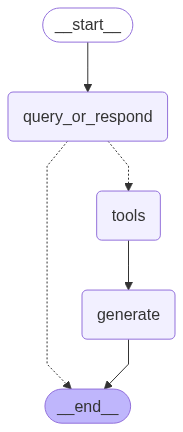

In [7]:
# To visualize flow: 
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))


### Testing

In [ ]:


# Specify an ID for the thread
config = {"configurable": {"thread_id": "abc123"}}

In [11]:
input_message='How do you win at power grid?'

graph.invoke({"messages": [{"role": "user", "content": input_message}]}, config=config)

c:\Users\Carlos Ivan\Documents\Projects\boardgames-assistant\.venv\lib\site-packages\langsmith\client.py:272: LangSmithMissingAPIKeyWarning: API key must be provided when using hosted LangSmith API
  warnings.warn(
Failed to send compressed multipart ingest: langsmith.utils.LangSmithAuthError: Authentication failed for https://api.smith.langchain.com/runs/multipart. HTTPError('401 Client Error: Unauthorized for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Unauthorized"}\n')trace=aacd9acb-f611-4bce-8c9b-de7250fb091c,id=aacd9acb-f611-4bce-8c9b-de7250fb091c; trace=aacd9acb-f611-4bce-8c9b-de7250fb091c,id=2cb23b66-f82f-48a5-a9f8-44ac33fc6287; trace=aacd9acb-f611-4bce-8c9b-de7250fb091c,id=9239e94b-b4b3-4699-8415-ef79f70e302d


{'messages': [AIMessage(content="I will search for 'how to win at power grid'.", additional_kwargs={'id': '1ab630ad-acc2-4d9b-91a1-514bc98d77e0', 'finish_reason': 'TOOL_CALL', 'tool_plan': "I will search for 'how to win at power grid'.", 'tool_calls': [{'id': 'retrieve_7eddh4sr81fj', 'type': 'function', 'function': {'name': 'retrieve', 'arguments': '{"query":"how to win at power grid"}'}}], 'token_count': {'input_tokens': 1434.0, 'output_tokens': 52.0}}, response_metadata={'id': '1ab630ad-acc2-4d9b-91a1-514bc98d77e0', 'finish_reason': 'TOOL_CALL', 'tool_plan': "I will search for 'how to win at power grid'.", 'tool_calls': [{'id': 'retrieve_7eddh4sr81fj', 'type': 'function', 'function': {'name': 'retrieve', 'arguments': '{"query":"how to win at power grid"}'}}], 'token_count': {'input_tokens': 1434.0, 'output_tokens': 52.0}}, id='run--9239e94b-b4b3-4699-8415-ef79f70e302d-0', tool_calls=[{'name': 'retrieve', 'args': {'query': 'how to win at power grid'}, 'id': 'retrieve_7eddh4sr81fj', 't

Failed to send compressed multipart ingest: langsmith.utils.LangSmithAuthError: Authentication failed for https://api.smith.langchain.com/runs/multipart. HTTPError('401 Client Error: Unauthorized for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Unauthorized"}\n')trace=aacd9acb-f611-4bce-8c9b-de7250fb091c,id=9239e94b-b4b3-4699-8415-ef79f70e302d; trace=aacd9acb-f611-4bce-8c9b-de7250fb091c,id=0c8d862c-e894-403c-8fa5-880c99e9ef11; trace=aacd9acb-f611-4bce-8c9b-de7250fb091c,id=0c8d862c-e894-403c-8fa5-880c99e9ef11; trace=aacd9acb-f611-4bce-8c9b-de7250fb091c,id=2cb23b66-f82f-48a5-a9f8-44ac33fc6287; trace=aacd9acb-f611-4bce-8c9b-de7250fb091c,id=e4d2f342-0b19-46de-9a12-3fa15244f6ae; trace=aacd9acb-f611-4bce-8c9b-de7250fb091c,id=b3f45673-9319-4760-924e-3c7054bb3be9; trace=aacd9acb-f611-4bce-8c9b-de7250fb091c,id=b3f45673-9319-4760-924e-3c7054bb3be9; trace=aacd9acb-f611-4bce-8c9b-de7250fb091c,id=e4d2f342-0b19-46de-9a12-3fa15244f6ae; trace=aacd9acb-f611-4bce-8c9b-de7250fb091c,id

{'messages': [HumanMessage(content='How do you win at power grid?', additional_kwargs={}, response_metadata={}, id='f1d55b6a-2c41-40a0-9992-309fb9a4ab7d'),
  AIMessage(content="I will search for 'how to win at power grid'.", additional_kwargs={'id': '1ab630ad-acc2-4d9b-91a1-514bc98d77e0', 'finish_reason': 'TOOL_CALL', 'tool_plan': "I will search for 'how to win at power grid'.", 'tool_calls': [{'id': 'retrieve_7eddh4sr81fj', 'type': 'function', 'function': {'name': 'retrieve', 'arguments': '{"query":"how to win at power grid"}'}}], 'token_count': {'input_tokens': 1434.0, 'output_tokens': 52.0}}, response_metadata={'id': '1ab630ad-acc2-4d9b-91a1-514bc98d77e0', 'finish_reason': 'TOOL_CALL', 'tool_plan': "I will search for 'how to win at power grid'.", 'tool_calls': [{'id': 'retrieve_7eddh4sr81fj', 'type': 'function', 'function': {'name': 'retrieve', 'arguments': '{"query":"how to win at power grid"}'}}], 'token_count': {'input_tokens': 1434.0, 'output_tokens': 52.0}}, id='run--9239e94b-b

Failed to send compressed multipart ingest: langsmith.utils.LangSmithAuthError: Authentication failed for https://api.smith.langchain.com/runs/multipart. HTTPError('401 Client Error: Unauthorized for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Unauthorized"}\n')trace=aacd9acb-f611-4bce-8c9b-de7250fb091c,id=16012d70-37a2-4d08-a088-65f477845385; trace=aacd9acb-f611-4bce-8c9b-de7250fb091c,id=d9a99764-c18c-437b-afd3-03309369a741; trace=aacd9acb-f611-4bce-8c9b-de7250fb091c,id=aacd9acb-f611-4bce-8c9b-de7250fb091c
Failed to send compressed multipart ingest: langsmith.utils.LangSmithAuthError: Authentication failed for https://api.smith.langchain.com/runs/multipart. HTTPError('401 Client Error: Unauthorized for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Unauthorized"}\n')trace=ef38c5cc-aff6-4358-8271-a36177b5f851,id=ef38c5cc-aff6-4358-8271-a36177b5f851; trace=ef38c5cc-aff6-4358-8271-a36177b5f851,id=e6ca9d96-d436-429f-9c13-064dbdbd5341; trace=ef38c5cc-

In [12]:
#input_message='How do you win at paleo?'
input_message='What was my last question?'
#input_message='Good morning Cohere chatbot!'
#input_message='Up to how many players can Monopoly be played?'


graph.invoke({"messages": [{"role": "user", "content": input_message}]}, config=config)

{'messages': [AIMessage(content='Your last question was: "How do you win at power grid?"', additional_kwargs={'id': 'd65349d9-446f-4935-9bf5-c029f38479ab', 'finish_reason': 'COMPLETE', 'content': 'Your last question was: "How do you win at power grid?"', 'token_count': {'input_tokens': 3251.0, 'output_tokens': 16.0}}, response_metadata={'id': 'd65349d9-446f-4935-9bf5-c029f38479ab', 'finish_reason': 'COMPLETE', 'content': 'Your last question was: "How do you win at power grid?"', 'token_count': {'input_tokens': 3251.0, 'output_tokens': 16.0}}, id='run--3bf7acff-3b52-41e0-8c4a-04afc40044d3-0', usage_metadata={'input_tokens': 3251, 'output_tokens': 16, 'total_tokens': 3267})]}


{'messages': [HumanMessage(content='How do you win at power grid?', additional_kwargs={}, response_metadata={}, id='f1d55b6a-2c41-40a0-9992-309fb9a4ab7d'),
  AIMessage(content="I will search for 'how to win at power grid'.", additional_kwargs={'id': '1ab630ad-acc2-4d9b-91a1-514bc98d77e0', 'finish_reason': 'TOOL_CALL', 'tool_plan': "I will search for 'how to win at power grid'.", 'tool_calls': [{'id': 'retrieve_7eddh4sr81fj', 'type': 'function', 'function': {'name': 'retrieve', 'arguments': '{"query":"how to win at power grid"}'}}], 'token_count': {'input_tokens': 1434.0, 'output_tokens': 52.0}}, response_metadata={'id': '1ab630ad-acc2-4d9b-91a1-514bc98d77e0', 'finish_reason': 'TOOL_CALL', 'tool_plan': "I will search for 'how to win at power grid'.", 'tool_calls': [{'id': 'retrieve_7eddh4sr81fj', 'type': 'function', 'function': {'name': 'retrieve', 'arguments': '{"query":"how to win at power grid"}'}}], 'token_count': {'input_tokens': 1434.0, 'output_tokens': 52.0}}, id='run--9239e94b-b

In [13]:
input_message='How do you win at Memoir?'


graph.invoke({"messages": [{"role": "user", "content": input_message}]}, config=config)

{'messages': [AIMessage(content="I will search for 'how to win at Memoir'.", additional_kwargs={'id': 'cc1f0a89-297f-485a-b953-2c6e948c6fef', 'finish_reason': 'TOOL_CALL', 'tool_plan': "I will search for 'how to win at Memoir'.", 'tool_calls': [{'id': 'retrieve_mex7nfeg8z2v', 'type': 'function', 'function': {'name': 'retrieve', 'arguments': '{"query":"how to win at Memoir"}'}}], 'token_count': {'input_tokens': 3280.0, 'output_tokens': 50.0}}, response_metadata={'id': 'cc1f0a89-297f-485a-b953-2c6e948c6fef', 'finish_reason': 'TOOL_CALL', 'tool_plan': "I will search for 'how to win at Memoir'.", 'tool_calls': [{'id': 'retrieve_mex7nfeg8z2v', 'type': 'function', 'function': {'name': 'retrieve', 'arguments': '{"query":"how to win at Memoir"}'}}], 'token_count': {'input_tokens': 3280.0, 'output_tokens': 50.0}}, id='run--e074975d-cdda-4063-b48d-1ec1176bea67-0', tool_calls=[{'name': 'retrieve', 'args': {'query': 'how to win at Memoir'}, 'id': 'retrieve_mex7nfeg8z2v', 'type': 'tool_call'}], usa

{'messages': [HumanMessage(content='How do you win at power grid?', additional_kwargs={}, response_metadata={}, id='f1d55b6a-2c41-40a0-9992-309fb9a4ab7d'),
  AIMessage(content="I will search for 'how to win at power grid'.", additional_kwargs={'id': '1ab630ad-acc2-4d9b-91a1-514bc98d77e0', 'finish_reason': 'TOOL_CALL', 'tool_plan': "I will search for 'how to win at power grid'.", 'tool_calls': [{'id': 'retrieve_7eddh4sr81fj', 'type': 'function', 'function': {'name': 'retrieve', 'arguments': '{"query":"how to win at power grid"}'}}], 'token_count': {'input_tokens': 1434.0, 'output_tokens': 52.0}}, response_metadata={'id': '1ab630ad-acc2-4d9b-91a1-514bc98d77e0', 'finish_reason': 'TOOL_CALL', 'tool_plan': "I will search for 'how to win at power grid'.", 'tool_calls': [{'id': 'retrieve_7eddh4sr81fj', 'type': 'function', 'function': {'name': 'retrieve', 'arguments': '{"query":"how to win at power grid"}'}}], 'token_count': {'input_tokens': 1434.0, 'output_tokens': 52.0}}, id='run--9239e94b-b

In [23]:
input_message='Which event cards are there in Tureluurs?'

answer=graph.invoke({"messages": [{"role": "user", "content": input_message}]}, config=config)

{'messages': [AIMessage(content="I will search for 'Tureluurs event cards'.", additional_kwargs={'id': 'b2905279-6db9-4425-bac6-1774874326ea', 'finish_reason': 'TOOL_CALL', 'tool_plan': "I will search for 'Tureluurs event cards'.", 'tool_calls': [{'id': 'retrieve_t1vc9x9edvxw', 'type': 'function', 'function': {'name': 'retrieve', 'arguments': '{"query":"Tureluurs event cards"}'}}], 'token_count': {'input_tokens': 1436.0, 'output_tokens': 52.0}}, response_metadata={'id': 'b2905279-6db9-4425-bac6-1774874326ea', 'finish_reason': 'TOOL_CALL', 'tool_plan': "I will search for 'Tureluurs event cards'.", 'tool_calls': [{'id': 'retrieve_t1vc9x9edvxw', 'type': 'function', 'function': {'name': 'retrieve', 'arguments': '{"query":"Tureluurs event cards"}'}}], 'token_count': {'input_tokens': 1436.0, 'output_tokens': 52.0}}, id='run--05813734-cb78-49d2-b3ac-92bc41bed3e3-0', tool_calls=[{'name': 'retrieve', 'args': {'query': 'Tureluurs event cards'}, 'id': 'retrieve_t1vc9x9edvxw', 'type': 'tool_call'}

In [24]:
answer

{'messages': [HumanMessage(content='Which event cards are there in Tureluurs?', additional_kwargs={}, response_metadata={}, id='21b1b14a-ff48-41e9-822e-95b692e8bf3f'),
  AIMessage(content="I will search for 'Tureluurs event cards'.", additional_kwargs={'id': 'b2905279-6db9-4425-bac6-1774874326ea', 'finish_reason': 'TOOL_CALL', 'tool_plan': "I will search for 'Tureluurs event cards'.", 'tool_calls': [{'id': 'retrieve_t1vc9x9edvxw', 'type': 'function', 'function': {'name': 'retrieve', 'arguments': '{"query":"Tureluurs event cards"}'}}], 'token_count': {'input_tokens': 1436.0, 'output_tokens': 52.0}}, response_metadata={'id': 'b2905279-6db9-4425-bac6-1774874326ea', 'finish_reason': 'TOOL_CALL', 'tool_plan': "I will search for 'Tureluurs event cards'.", 'tool_calls': [{'id': 'retrieve_t1vc9x9edvxw', 'type': 'function', 'function': {'name': 'retrieve', 'arguments': '{"query":"Tureluurs event cards"}'}}], 'token_count': {'input_tokens': 1436.0, 'output_tokens': 52.0}}, id='run--05813734-cb78

In [26]:
answer['messages'][-1].content

'The context provided does not specify the exact Event cards in Tureluurs. However, it mentions that Events have various effects, such as causing birds to fly away or allowing players to retrieve a Bird card from the discard pile. These effects can be either negative or positive, adding unpredictability to the game.'

'The context provided does not specify the exact Event cards in Tureluurs. However, it mentions that Events have various effects, such as causing birds to fly away or allowing players to retrieve a Bird card from the discard pile. These effects can be either negative or positive, adding unpredictability to the game.'
